# Map of New York Metro and Train Network
Data source: General Transit Feed Specification.

Coding references:
- https://city2graph.net/latest/examples/gtfs.html
- Gemini: https://share.gemini.google/Qb47znLylp7r
- Claude (chat v2): https://claude.ai/share/c478d277-53d3-4d62-bcd9-c242b6322626
- Networkx documentation: https://networkx.org/documentation/stable/index.html

Note: Gemini was a lot more helpful for research programming things. Taught me a lot more.

# NOTES
- Check exactly which cities are showing up and which ones are not and why (tere are meant to be either 423 or 472 smth like that)
- Check the bottlenecks and most connected stations. Where do these lists overlap? Where don't they?

# Code

In [2]:
import osmnx as ox
import matplotlib.pyplot as plt
import folium
import mapclassify
import pandas as pd
import networkx as nx
import partridge as ptg
from geopy.distance import geodesic
import numpy as np
from sklearn.cluster import DBSCAN


/Users/andreagarcia/Desktop/capstone/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# METHOD 1 WITH OSMNX
Better for visualzation, but harder for calculations because it plots the actual tracks

In [ ]:
'''
city = "New York City, New York, USA"
filter = '["railway"~"subway"]'

# Download graph for selected city
osmnx_graph = ox.graph_from_place(
    city,
    retain_all = True,
    truncate_by_edge = True,
    simplify = True,
    custom_filter=filter
)

# Turn data into GeoDataFrame
edges_gdf = ox.graph_to_gdfs(osmnx_graph, nodes=False)

# Create interactive map
interactive_map = edges_gdf.explore()
interactive_map.save("osmnx_nY_metro.html")
'''

# METHOD 2 GFTS DATA

In [4]:
# Load data with partridge
gtfs_path = "NY_data"
source = ptg.load_feed(gtfs_path)

stops = source.stops
stop_times = source.stop_times
trips = source.trips
routes = source.routes
shapes = source.shapes if hasattr(source, "shapes") else None

# -------------------- CLUSTER STOPS --------------------
#  (sanity check: always go for bradway junction)
stops["clean_name"] = stops["stop_name"].str.strip() # Just in case, remove spaces at the end

MAX_HUB_DISTANCE_KM = 0.15

# Map each original stop_id to a new unified node_id
stop_to_unified_node = {}
unified_nodes = {}  # new_node_id -> {name, lat, lon}

node_counter = 0

for name, group in stops.groupby("clean_name"):
    coords = group[["stop_lat", "stop_lon"]].values

    if len(group) == 1:
        # Unique station name, no clustering needed
        node_id = f"node_{node_counter}"
        node_counter += 1
        stop_to_unified_node[group.iloc[0]["stop_id"]] = node_id
        unified_nodes[node_id] = {
            "name": name,
            "lat": group.iloc[0]["stop_lat"],
            "lon": group.iloc[0]["stop_lon"],
        }
    else:
        # Convert lat/lon to radians for Haversine distance clustering
        coords_rad = np.radians(coords)
        kms_per_radian = 6371.0088
        epsilon = MAX_HUB_DISTANCE_KM / kms_per_radian

        db = DBSCAN(
            eps=epsilon, min_samples=1, metric="haversine"
        ).fit(coords_rad)

        for cluster_label in set(db.labels_):
            cluster_mask = db.labels_ == cluster_label
            cluster_stops = group[cluster_mask]

            node_id = f"node_{node_counter}"
            node_counter += 1

            # Centroid of the station complex
            mean_lat = cluster_stops["stop_lat"].mean()
            mean_lon = cluster_stops["stop_lon"].mean()

            unified_nodes[node_id] = {
                "name": name,
                "lat": mean_lat,
                "lon": mean_lon,
            }

            for sid in cluster_stops["stop_id"]:
                stop_to_unified_node[sid] = node_id


# -------------------- BUILD GRAPH --------------------
G = nx.Graph()

for node_id, data in unified_nodes.items():
    G.add_node(
        node_id, name=data["name"], pos=(data["lat"], data["lon"])
    )

# Remap stop_times to new unified nodes
stop_times["node_id"] = stop_times["stop_id"].map(stop_to_unified_node)

# Connect edges along trip sequences
stop_times_sorted = stop_times.sort_values(["trip_id", "stop_sequence"])

for _, trip_group in stop_times_sorted.groupby("trip_id"):
    nodes_seq = trip_group["node_id"].dropna().tolist()
    for u, v in zip(nodes_seq[:-1], nodes_seq[1:]):
        if u != v:
            G.add_edge(u, v)

print(f"Nodes (Stations): {G.number_of_nodes()}\nEdges: {G.number_of_edges()}")

Nodes (Stations): 467
Edges: 573


In [5]:
# Create map using Folium
map = folium.Map(location=[40.7128, -74.0060], zoom_start = 12, tiles='CartoDB dark_matter')

for u, v in G.edges():
    n1, n2 = G.nodes[u], G.nodes[v]

    folium.PolyLine(
        [n1['pos'], n2['pos']],
        color= "#346beb",
        weight=3,
        opacity= 0.7
    ).add_to(map)

for node, data in G.nodes(data=True):
    popup_content = f"<b>{data['name']}</b><br>Station ID: {node}<br>Connections: {G.degree(node)}"
    
    folium.CircleMarker(
        location=data['pos'],
        radius= 7,
        color= "#ffffff",
        weight=1,
        fill=True,
        fill_color= "#f01d25",
        fill_opacity=0.9,
        tooltip=data['name'],                  # Shows name on hover
        popup=folium.Popup(popup_content, max_width=200) # Shows info card on click
    ).add_to(map)

map.save('gfts_NY_metro.html')

# Network Summary Statistis

In [6]:
# Calculate the important stats for the main component (drop Staten Island)
largest_component_nodes = max(nx.connected_components(G), key=len)
G_big = G.subgraph(largest_component_nodes).copy()

degree_dict  = dict(G_big.degree())
top_stations = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_named    = [(G_big.nodes[sid].get('name', sid), deg) for sid, deg in top_stations]

betweenness  = nx.betweenness_centrality(G_big)
top_between  = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
top_between_named = [(G_big.nodes[sid].get('name', sid), round(val, 4))
                     for sid, val in top_between]

avg_path     = nx.average_shortest_path_length(G_big)
fiedler      = nx.algebraic_connectivity(G_big)

# Print summary
print("=" * 55)
print("  NYC SUBWAY — NETWORK SUMMARY")
print("=" * 55)

print(f"\n  Stations (nodes):       {G_big.number_of_nodes()}")
print(f"  Connections (edges):    {G_big.number_of_edges()}")

print(f"\n  Avg. shortest path:     {avg_path:.4f} stops")
print(f"  Algebraic connectivity: {fiedler:.6f}")

print(f"\n  Degree:                 {sum(degree_dict.values())/len(degree_dict)}")

print("\n  Top 10 — Most connected stations (degree):")
for i, (name, deg) in enumerate(top_named, 1):
    print(f"\t{i:>2}. {name:<30} {deg} connections")

print("\n  Top 10 — Biggest bottlenecks (betweenness centrality):")
for i, (name, val) in enumerate(top_between_named, 1):
    print(f"\t{i:>2}. {name:<30} {val}")

print("=" * 55)

  NYC SUBWAY — NETWORK SUMMARY

  Stations (nodes):       446
  Connections (edges):    551

  Avg. shortest path:     12.3193 stops
  Algebraic connectivity: 0.005944

  Degree:                 2.4708520179372195

  Top 10 — Most connected stations (degree):
	 1. 14 St-Union Sq                 10 connections
	 2. Atlantic Av-Barclays Ctr       9 connections
	 3. Broadway Junction              9 connections
	 4. Times Sq-42 St                 9 connections
	 5. Canal St                       8 connections
	 6. 59 St-Columbus Circle          7 connections
	 7. Jay St-MetroTech               7 connections
	 8. 145 St                         6 connections
	 9. 34 St-Herald Sq                6 connections
	10. Fulton St                      6 connections

  Top 10 — Biggest bottlenecks (betweenness centrality):
	 1. 14 St-Union Sq                 0.4016
	 2. Canal St                       0.3775
	 3. Atlantic Av-Barclays Ctr       0.296
	 4. Grand Central-42 St            0.2823
	 5. Times

Saved degree_dist.png


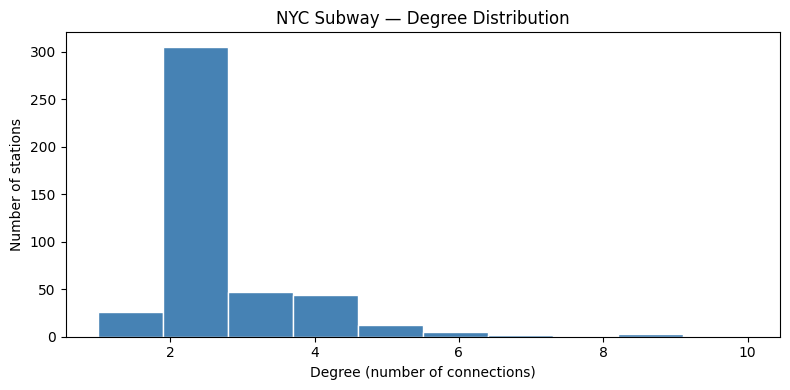

In [ ]:
# Histogram of degree distribution
degrees_list = [d for _, d in G_big.degree()]
plt.figure(figsize=(8,4))
plt.hist(degrees_list, bins=10, color='steelblue', edgecolor='white')
plt.xlabel("Degree (number of connections)")
plt.ylabel("Number of stations")
plt.title("NYC Subway — Degree Distribution")
plt.tight_layout()
print("Saved degree_dist.png")
#plt.savefig("degree_dist.png")